## Lab5

In this assignment you will use the `Weekly` data set, which is part of the `ISLP` package. This data is similar in nature to the `Smarket` data from the classification practice lab, except that it contains 1,089 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

In [1]:
# Import your libraries here
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Next load the `Weekly` data set.

In [2]:
Weekly = load_data('Weekly')
Weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


**(a) Produce some numerical and graphical summaries of the `Weekly` data. Do there appear to be any patterns? Do you notice any correlations?**

In [3]:
Weekly.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


<Axes: >

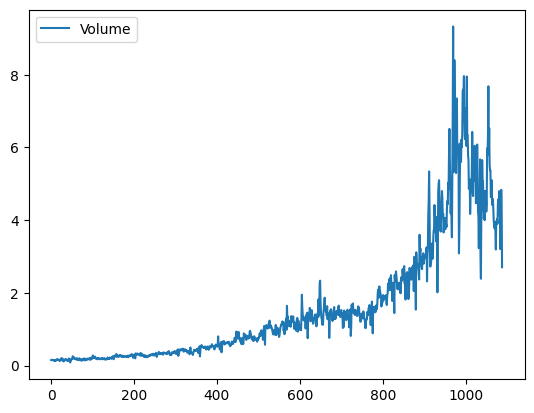

In [4]:
Weekly.plot(y='Volume')

Summarize and comment on your findings in this markdown cell:

Volume appears to have a positive correlation within this dataset

**(b) Use the full data set and the `statsmodels`'s logistic regression function to perform a logistic regression with `Direction` as the response and the five lag variables plus `Volume` as predictors. Also use ISLP `summary` function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?**

In [5]:
allvars = Weekly.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(Weekly)
y = Weekly.Direction == 'Up'
glm = sm.GLM(y,
             X,
             family=sm.families.Binomial())
results = glm.fit()
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Mon, 13 Oct 2025   Deviance:                       1486.4
Time:                        14:32:45   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2669      0.086      3.106      0.0

In [6]:
results.pvalues

intercept    0.001899
Lag1         0.118144
Lag2         0.029601
Lag3         0.546924
Lag4         0.293653
Lag5         0.583348
Volume       0.537675
dtype: float64

(Summarize and comment on your findings in this markdown cell)

There are 2 values that are statistically significant, intercept and Lag2, both of these are significant due to the p value below 0.05.

**(c) Construct the confusion matrix, and compute and interpret the various performance metrics (accuracy, precision, recall, FPR). Note that to obtain class predictions you need to manually set a threshold. Here use the default threshold of 0.5.**

In [14]:
probs = results.predict()
labels = np.array(['Down'] * len(y))
labels[probs>0.5] = 'Up'
confusionTable = confusion_table(labels, Weekly.Direction)
confusionTable

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [ ]:
# accuracy
print(f'Accuracy: {np.mean(labels == Weekly.Direction)*100:.2f}%')
# precision
print(f'Precision: {}')

Accuracy: 56.11%


AttributeError: 'DataFrame' object has no attribute 'precision'

(Summarize and comment on your findings in this markdown cell)

**(d) Now fit the `statsmodels`'s logistic regression model using a training data period from 1990 to 2008, with `Lag2` as the only predictor. Use the held-out data (that is, the data from 2009 and 2010) as your test set. Compute the confusion matrix and the overall fraction of correct predictions for the train and test sets (i.e. the train and test accuracy).**

(Summarize and comment on your findings in this markdown cell)

**(e) Repeat (d) using LDA.**

(Summarize and comment on your findings in this markdown cell)

**(f) Repeat (d) using QDA.**

(Summarize and comment on your findings in this markdown cell)

**(g) Repeat (d) using KNN with K = 1.**

(Summarize and comment on your findings in this markdown cell)

**(h) Repeat (d) using naive Bayes.**

(Summarize and comment on your findings in this markdown cell)

**(i) Which of these methods appears to provide the best results on
this data?**

(Summarize and comment on your findings in this markdown cell)

**(j) Now repeat part (d), this time using both `Lag1` and `Lag2` as predictors. Compare your findings with the ones from (d). Do you notice anything unexpected?**

(Summarize and comment on your findings in this markdown cell)

**(k) Using again `Lag2` as the only predictor, experiment with different valus of $K$ in KNN by performing KNN parameter tuning. Which value of $K$ achieves the best overall performance on the held-out data?**

(Summarize and comment on your findings in this markdown cell)

**(l) Open-ended section: Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data.**

(Summarize and comment on your findings in this markdown cell)